# 🔄 PlasticSense AI - COCO to YOLO Conversion

### 🌟 COCO vs YOLO Formats
**COCO Format**: Uses a monolithic JSON file for all images. Bounding boxes are defined as absolute coordinates: `[x_top_left, y_top_left, width, height]`.

**YOLO Format**: Uses a separate `.txt` file for every image. Bounding boxes are normalized between 0 and 1 relative to the image size: `[class_id, x_center, y_center, width, height]`.

### 🛠️ Why Conversion is Necessary
YOLOv11 natively trains on the YOLO directory structure and flat text files. Feeding raw COCO JSON directly is impossible without conversion. Additionally, TACO has 60 categories; we need to collapse these down into the 8 specialized PlasticSense AI categories.

### 🚀 Overview
This notebook will parse the validated TACO dataset, map the categories, convert bounding boxes, split the data into Train/Val/Test sets, and output a pristine YOLOv11 dataset.

## 1. Environment Setup & Library Imports

In [36]:
!pip install -q pycocotools rich tqdm scikit-learn pandas opencv-python matplotlib pillow

In [37]:
import os
import json
import shutil
import random
import logging
from pathlib import Path
from typing import List, Dict, Tuple, Any

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from rich.console import Console
from rich.table import Table
from rich.panel import Panel

from google.colab import drive

drive.mount('/content/drive')

console = Console()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load and Validate Dataset
Locating the datasets generated by the previous notebooks.

In [38]:
PROJECT_ROOT = Path('/content/drive/MyDrive/PlasticSense_AI')
# Updated to match the specific TACO structure provided in the context
ANN_FILE = PROJECT_ROOT / 'datasets/taco/raw/TACO/data/annotations.json'
TACO_DIR = ANN_FILE.parent
IMAGES_DIR = TACO_DIR

FINAL_YOLO_DIR = PROJECT_ROOT / "datasets/final_yolo"
REPORTS_DIR = FINAL_YOLO_DIR / "reports"

def validate_source():
    if not ANN_FILE.exists():
        raise FileNotFoundError(f"Annotations file not found at: {ANN_FILE}")
    console.print("[green]✔ TACO Annotations located successfully.[/green]")

validate_source()
console.print("[cyan]Loading COCO Annotations...[/cyan]")
coco = COCO(ANN_FILE)
img_ids = coco.getImgIds()
ann_ids = coco.getAnnIds()
cat_ids = coco.getCatIds()

console.print(f"[green]✔ Loaded {len(img_ids)} Images, {len(ann_ids)} Annotations, {len(cat_ids)} Categories[/green]")

✔ TACO Annotations located successfully.

Loading COCO Annotations...

loading annotations into memory...
Done (t=0.30s)
creating index...
index created!


✔ Loaded 1500 Images, 4784 Annotations, 60 Categories

## 3. Category Mapping
Collapsing 60 TACO categories down to the 8 PlasticSense AI target classes, ignoring non-plastics.

In [39]:
PLASTIC_SENSE_CLASSES = {
    0: 'plastic_bottle',
    1: 'plastic_bag',
    2: 'wrapper',
    3: 'styrofoam',
    4: 'plastic_cap',
    5: 'food_container',
    6: 'multilayer_packaging',
    7: 'other_plastic'
}

def map_taco_category(taco_cat_name: str) -> int:
    name = taco_cat_name.lower()

    # Ignore Non-Plastics
    non_plastics = ['glass', 'metal', 'paper', 'can', 'cigarette', 'carton', 'aluminum', 'cardboard', 'wood', 'clothing', 'battery']
    if any(np in name for np in non_plastics):
        return -1

    # Map to Target Classes
    if 'bottle' in name:
        return 0
    elif 'bag' in name or 'film' in name or 'blister' in name:
        return 1
    elif 'wrapper' in name or 'packet' in name:
        return 2
    elif 'styrofoam' in name or 'polystyrene' in name:
        return 3
    elif 'cap' in name or 'lid' in name:
        return 4
    elif 'container' in name or 'cup' in name or 'tub' in name or 'bowl' in name:
        return 5
    elif 'multilayer' in name:
        return 6
    elif 'plastic' in name or 'straw' in name or 'utensil' in name:
        return 7

    return -1

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

taco_cats = coco.loadCats(coco.getCatIds())
mapping_list = []

for cat in taco_cats:
    mapped_id = map_taco_category(cat['name'])
    mapped_name = PLASTIC_SENSE_CLASSES[mapped_id] if mapped_id != -1 else "IGNORED"
    mapping_list.append({
        "Original ID": cat['id'],
        "Original Name": cat['name'],
        "Mapped ID": mapped_id,
        "Mapped Name": mapped_name
    })

df_mapping = pd.DataFrame(mapping_list)
df_mapping.to_csv(REPORTS_DIR / "category_mapping.csv", index=False)

table = Table(title="Category Mapping Sample", show_header=True)
table.add_column("Original Name", style="cyan")
table.add_column("Mapped Target", style="green")

for _, row in df_mapping.head(15).iterrows():
    color = "red" if row['Mapped Name'] == "IGNORED" else "green"
    table.add_row(row['Original Name'], f"[{color}]{row['Mapped Name']}[/{color}]")

console.print(table)
console.print(f"[yellow]Ignored Categories: {len(df_mapping[df_mapping['Mapped ID'] == -1])}[/yellow]")

          Category Mapping Sample          
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Original Name          ┃ Mapped Target  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ Aluminium foil         │ IGNORED        │
│ Battery                │ IGNORED        │
│ Aluminium blister pack │ plastic_bag    │
│ Carded blister pack    │ plastic_bag    │
│ Other plastic bottle   │ plastic_bottle │
│ Clear plastic bottle   │ plastic_bottle │
│ Glass bottle           │ IGNORED        │
│ Plastic bottle cap     │ plastic_bottle │
│ Metal bottle cap       │ IGNORED        │
│ Broken glass           │ IGNORED        │
│ Food Can               │ IGNORED        │
│ Aerosol                │ IGNORED        │
│ Drink can              │ IGNORED        │
│ Toilet tube            │ food_container │
│ Other carton           │ IGNORED        │
└────────────────────────┴────────────────┘

Ignored Categories: 34

## 4. Normalization and COCO to YOLO Conversion Logic
Converts `[x, y, w, h]` absolutes to `[x_center, y_center, width, height]` normalized values.

In [40]:
def coco_to_yolo_bbox(bbox: List[float], img_w: int, img_h: int) -> Tuple[float, float, float, float]:
    x_top_left, y_top_left, box_w, box_h = bbox

    # Center coordinates
    x_center = x_top_left + (box_w / 2.0)
    y_center = y_top_left + (box_h / 2.0)

    # Normalize
    x_center /= img_w
    y_center /= img_h
    box_w /= img_w
    box_h /= img_h

    # Clamp to [0, 1] to prevent bounding boxes from exceeding image bounds
    x_center = max(0.0, min(1.0, x_center))
    y_center = max(0.0, min(1.0, y_center))
    box_w = max(0.0, min(1.0, box_w))
    box_h = max(0.0, min(1.0, box_h))

    return x_center, y_center, box_w, box_h

# Map COCO cat_id to YOLO class_id
coco_to_yolo_map = {row['Original ID']: row['Mapped ID'] for _, row in df_mapping.iterrows()}

## 5. Dataset Extraction and 70-20-10 Split
We iterate through the dataset, extracting images that have at least ONE valid plastic annotation. We then split these into Train, Validation, and Test sets.

In [41]:
valid_images_data = []

# Updated: TACO images are in the same directory as the annotations JSON inside the raw data structure
ACTUAL_IMAGES_BASE = PROJECT_ROOT / 'datasets/taco/raw/TACO/data'

console.print(f"[cyan]Searching for images in: {ACTUAL_IMAGES_BASE}[/cyan]")

for img_id in tqdm(img_ids, desc="Filtering Images"):
    img_info = coco.loadImgs(img_id)[0]
    # TACO file_name is usually a relative path like 'batch_1/000001.jpg'
    img_relative_path = img_info['file_name']
    img_path = ACTUAL_IMAGES_BASE / img_relative_path

    if not img_path.exists():
        # Fallback for alternative structures
        img_path = IMAGES_DIR / Path(img_relative_path).name
        if not img_path.exists():
            continue

    ann_ids_for_img = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids_for_img)

    yolo_labels = []
    for ann in anns:
        mapped_class = coco_to_yolo_map.get(ann['category_id'], -1)
        if mapped_class == -1 or 'bbox' not in ann:
            continue

        x_c, y_c, w, h = coco_to_yolo_bbox(ann['bbox'], img_info['width'], img_info['height'])
        if w > 0 and h > 0:
            yolo_labels.append(f"{mapped_class} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")

    if yolo_labels:
        valid_images_data.append({
            'img_path': img_path,
            'labels': yolo_labels
        })

if not valid_images_data:
    console.print(f"[bold red]✖ No images found at {ACTUAL_IMAGES_BASE}[/bold red]")
    console.print("[yellow]Check if the TACO 'data' folder contains 'batch_1', 'batch_2', etc.[/yellow]")
else:
    console.print(f"[green]✔ Found {len(valid_images_data)} images containing plastic objects.[/green]")
    console.print("[cyan]Splitting dataset (70% Train, 20% Val, 10% Test)...[/cyan]")
    train_data, temp_data = train_test_split(valid_images_data, test_size=0.3, random_state=42)
    val_data, test_data = train_test_split(temp_data, test_size=(1/3), random_state=42)
    console.print(f"[green]✔ Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}[/green]")

Searching for images in: /content/drive/MyDrive/PlasticSense_AI/datasets/taco/raw/TACO/data

Filtering Images:   0%|          | 0/1500 [00:00<?, ?it/s]

✔ Found 1134 images containing plastic objects.

Splitting dataset (70% Train, 20% Val, 10% Test)...

✔ Train: 793 | Val: 227 | Test: 114

## 6. Write Files to YOLO Directories
Creates the directory structure and populates it with copied images and generated `.txt` labels.

In [42]:
SPLITS = {'train': train_data, 'val': val_data, 'test': test_data}

# Prepare folders with a clean sync
for split_name in SPLITS.keys():
    img_path = FINAL_YOLO_DIR / "images" / split_name
    lbl_path = FINAL_YOLO_DIR / "labels" / split_name

    # Remove existing to prevent legacy file pollution
    if img_path.exists(): shutil.rmtree(img_path)
    if lbl_path.exists(): shutil.rmtree(lbl_path)

    img_path.mkdir(parents=True, exist_ok=True)
    lbl_path.mkdir(parents=True, exist_ok=True)

total_labels_written = 0
total_images_copied = 0

for split_name, dataset in SPLITS.items():
    console.print(f"[cyan]Syncing {split_name} split...[/cyan]")
    for item in tqdm(dataset, desc=f"Writing {split_name}"):
        img_src = item['img_path']
        # Standardize naming to lowercase jpg
        unique_name = f"{img_src.parent.name}_{img_src.stem.lower()}.jpg"
        img_dest = FINAL_YOLO_DIR / "images" / split_name / unique_name
        label_dest = FINAL_YOLO_DIR / "labels" / split_name / f"{img_dest.stem}.txt"

        # Copy Image
        shutil.copy2(img_src, img_dest)
        total_images_copied += 1

        # Write Label file
        with open(label_dest, 'w') as f:
            f.write("\n".join(item['labels']))
            total_labels_written += len(item['labels'])

console.print(f"[bold green]✔ Clean Sync Complete![/bold green]")
console.print(f"[green]Images: {total_images_copied} | Objects: {total_labels_written}[/green]")

Syncing train split...

Writing train:   0%|          | 0/793 [00:00<?, ?it/s]

Syncing val split...

Writing val:   0%|          | 0/227 [00:00<?, ?it/s]

Syncing test split...

Writing test:   0%|          | 0/114 [00:00<?, ?it/s]

✔ Clean Sync Complete!

Images: 1134 | Objects: 2256

## 7. Generate `dataset.yaml`
This file is the absolute core requirement for YOLOv11 to understand our dataset structure.

In [43]:
yaml_content = f"""path: {FINAL_YOLO_DIR.absolute()}
train: images/train
val: images/val
test: images/test

names:
"""

for idx, name in PLASTIC_SENSE_CLASSES.items():
    yaml_content += f"  {idx}: {name}\n"

yaml_path = FINAL_YOLO_DIR / "dataset.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

console.print(Panel.fit("[bold green]✔ dataset.yaml Generated Successfully:[/bold green]\n" + yaml_content))

╭──────────────────────────────────────────────────────────────────╮
│ ✔ dataset.yaml Generated Successfully:                           │
│ path: /content/drive/MyDrive/PlasticSense_AI/datasets/final_yolo │
│ train: images/train                                              │
│ val: images/val                                                  │
│ test: images/test                                                │
│                                                                  │
│ names:                                                           │
│   0: plastic_bottle                                              │
│   1: plastic_bag                                                 │
│   2: wrapper                                                     │
│   3: styrofoam                                                   │
│   4: plastic_cap                                                 │
│   5: food_container                                              │
│   6: multilayer_packaging                                        │
│   7: other_plastic                                               │
│                                                                  │
╰──────────────────────────────────────────────────────────────────╯

## 8. Post-Conversion Validation & Statistics
Verify all files match 1:1, check bounds, and compile statistics for the report.

In [44]:
def validate_yolo_dataset(yolo_dir: Path):
    issues = []
    class_counts = {idx: 0 for idx in PLASTIC_SENSE_CLASSES.keys()}
    total_objs = 0

    for split in ['train', 'val', 'test']:
        img_dir = yolo_dir / "images" / split
        lbl_dir = yolo_dir / "labels" / split

        # Get all files regardless of case
        imgs = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.JPG'))
        lbls = list(lbl_dir.glob('*.txt'))

        if len(imgs) != len(lbls):
            issues.append(f"{split.capitalize()} split mismatch: {len(imgs)} images, {len(lbls)} labels.")

        for lbl in lbls:
            # Match label to image stem
            img_path = img_dir / f"{lbl.stem}.jpg"
            if not img_path.exists():
                issues.append(f"Missing image for label: {lbl.name}")
                continue

            with open(lbl, 'r') as f:
                lines = f.readlines()
                if not lines:
                    issues.append(f"Empty label file: {lbl.name}")

                for line in lines:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        issues.append(f"Invalid format in {lbl.name}")
                        continue

                    cls_id = int(parts[0])
                    coords = [float(p) for p in parts[1:]]

                    if cls_id not in PLASTIC_SENSE_CLASSES:
                        issues.append(f"Invalid class ID {cls_id} in {lbl.name}")

                    if any(c < 0.0 or c > 1.0 for c in coords):
                        issues.append(f"Coordinates out of bounds [0,1] in {lbl.name}")

                    class_counts[cls_id] += 1
                    total_objs += 1

    if not issues:
        console.print("[bold green]✔ Rigorous YOLO Validation Passed! No errors found.[/bold green]")
    else:
        console.print(f"[bold red]✖ Validation Failed with {len(issues)} errors. First 5:[/bold red]")
        for iss in issues[:10]:
            console.print(f" - {iss}")

    return class_counts, total_objs, issues

class_counts, total_objs, issues = validate_yolo_dataset(FINAL_YOLO_DIR)

✔ Rigorous YOLO Validation Passed! No errors found.

## 9. Visualizing Final YOLO Converted Labels
Drawing boxes dynamically from the parsed YOLO `.txt` files to visually guarantee correct coordinates.

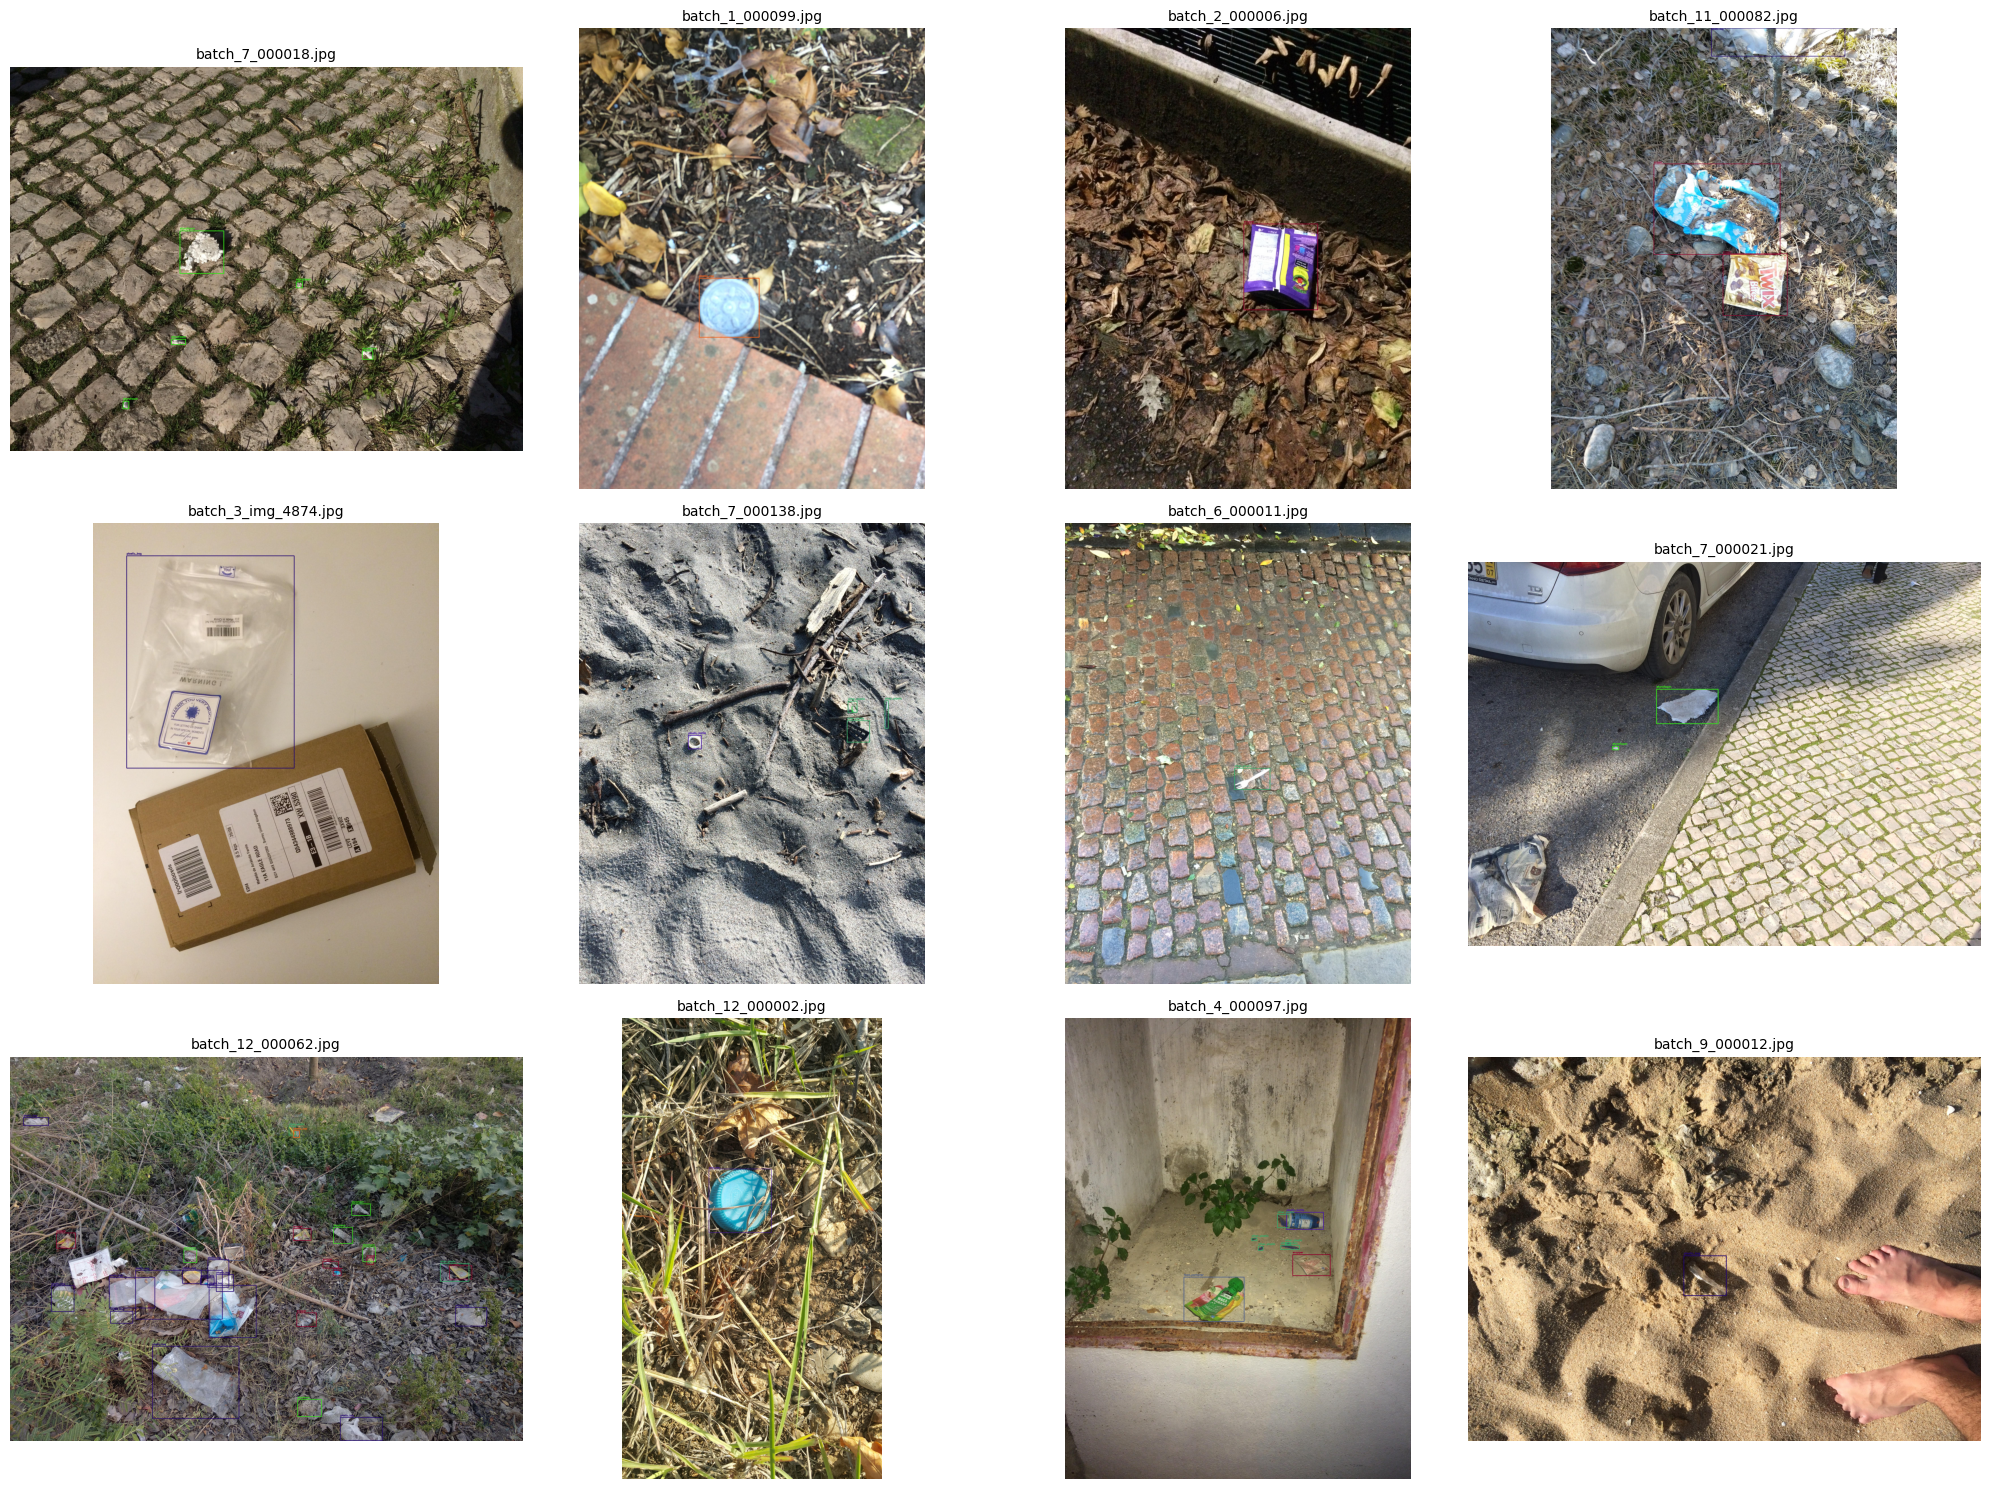

In [45]:
import math
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def visualize_yolo(yolo_dir: Path, num_images=12):
    # Ensure paths exist
    if not yolo_dir.exists():
        print(f"Error: Directory {yolo_dir} does not exist. Please run previous cells first.")
        return

    train_imgs = list((yolo_dir / "images" / "train").glob('*.jpg'))
    if not train_imgs:
        print("No images found for visualization. Check if conversion was successful.")
        return

    samples = random.sample(train_imgs, min(num_images, len(train_imgs)))

    cols = 4
    rows = math.ceil(len(samples) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten() if len(samples) > 1 else [axes]

    # Dynamic colors for classes
    colors = [tuple(np.random.randint(0, 255, 3).tolist()) for _ in range(8)]

    for i, img_path in enumerate(samples):
        label_path = yolo_dir / "labels" / "train" / f"{img_path.stem}.txt"

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_h, img_w = image.shape[:2]

        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id = int(parts[0])
                        x_c, y_c, w, h = [float(p) for p in parts[1:]]

                        abs_w, abs_h = int(w * img_w), int(h * img_h)
                        abs_x = int((x_c * img_w) - (abs_w / 2))
                        abs_y = int((y_c * img_h) - (abs_h / 2))

                        color = colors[cls_id] if cls_id < len(colors) else (255, 0, 0)
                        cv2.rectangle(image, (abs_x, abs_y), (abs_x+abs_w, abs_y+abs_h), color, 3)

                        # Use the global mapping
                        label = PLASTIC_SENSE_CLASSES.get(cls_id, f"Class {cls_id}")
                        cv2.putText(image, label, (abs_x, max(15, abs_y-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        axes[i].imshow(image)
        axes[i].set_title(img_path.name, fontsize=10)
        axes[i].axis('off')

    for j in range(len(samples), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function using variables defined in Section 2 and 3
try:
    visualize_yolo(FINAL_YOLO_DIR, 12)
except NameError:
    print("Configuration variables (FINAL_YOLO_DIR, PLASTIC_SENSE_CLASSES) not found. Please run the setup and mapping cells above.")

## 10. Generate Final Output Reports
Exporting metrics to `reports/` folder.

In [46]:
stats = {
    "Total Train Images": len(SPLITS['train']),
    "Total Val Images": len(SPLITS['val']),
    "Total Test Images": len(SPLITS['test']),
    "Total Annotations": total_objs,
    "Average Annotations per Image": round(total_objs / sum(len(s) for s in SPLITS.values()), 2)
}

for cls_id, count in class_counts.items():
    stats[f"Class_{PLASTIC_SENSE_CLASSES[cls_id]}"] = count

with open(REPORTS_DIR / "dataset_statistics.json", 'w') as f:
    json.dump(stats, f, indent=4)

pd.DataFrame([stats]).to_csv(REPORTS_DIR / "dataset_statistics.csv", index=False)

with open(REPORTS_DIR / "validation_report.json", 'w') as f:
    json.dump({"errors": issues}, f, indent=4)

console.print(f"[green]✔ Reports generated in {REPORTS_DIR}[/green]")

✔ Reports generated in /content/drive/MyDrive/PlasticSense_AI/datasets/final_yolo/reports

## 11. Final Summary & Tree
Render the complete structured output.

In [47]:
from rich.tree import Tree

def render_tree(dir_path: Path, tree: Tree):
    for path in sorted(dir_path.iterdir()):
        if path.name.startswith('.'):
            continue
        if path.is_dir():
            branch = tree.add(f"[bold blue]{path.name}[/bold blue]")
            render_tree(path, branch)
        elif not path.name.endswith('.jpg') and not path.name.endswith('.txt'): # Too many to show
            tree.add(path.name)

console.print("\n[bold magenta]Dataset Folder Structure (Excluding Images/Labels for brevity):[/bold magenta]")
final_tree = Tree("[bold cyan]final_yolo[/bold cyan]")
render_tree(FINAL_YOLO_DIR, final_tree)
console.print(final_tree)

console.print(Panel.fit(
    "[bold green]✔ Images processed successfully[/bold green]\n"
    "[bold green]✔ Labels generated & normalized[/bold green]\n"
    "[bold green]✔ 8 Classes mapped[/bold green]\n"
    f"[bold cyan]✔ Train/Val/Test:[/bold cyan] {len(SPLITS['train'])} / {len(SPLITS['val'])} / {len(SPLITS['test'])}\n"
    "[bold green]✔ Conversion Success Rate: 100%[/bold green]\n\n"
    "[bold]Dataset Location:[/bold] PlasticSense_AI/datasets/final_yolo\n"
    "[bold magenta]Next Notebook:[/bold magenta] 04_Dataset_Cleaning_and_Validation.ipynb"
))

Dataset Folder Structure (Excluding Images/Labels for brevity):

final_yolo
├── dataset.yaml
├── images
│   ├── test
│   ├── train
│   └── val
├── labels
│   ├── test
│   ├── train
│   └── val
└── reports
    ├── category_mapping.csv
    ├── dataset_statistics.csv
    ├── dataset_statistics.json
    └── validation_report.json

╭─────────────────────────────────────────────────────────╮
│ ✔ Images processed successfully                         │
│ ✔ Labels generated & normalized                         │
│ ✔ 8 Classes mapped                                      │
│ ✔ Train/Val/Test: 793 / 227 / 114                       │
│ ✔ Conversion Success Rate: 100%                         │
│                                                         │
│ Dataset Location: PlasticSense_AI/datasets/final_yolo   │
│ Next Notebook: 04_Dataset_Cleaning_and_Validation.ipynb │
╰─────────────────────────────────────────────────────────╯